### Import Libraries


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Load data and information 


In [ ]:
df=pd.read_csv("tmdb_movies_cleaned.csv")
df

,adult,original_language,original_title,popularity,release_date,video,vote_average,vote_count,genre_ids
0,False,en,The Shawshank Redemption,31.3466,1994-09-23,False,8.715,29596,"[18, 80]"
1,False,en,The Godfather,29.5916,1972-03-14,False,8.687,22357,"[18, 80]"
2,False,en,The Godfather Part II,19.1848,1974-12-20,False,8.570,13519,"[18, 80]"
3,False,en,Schindler's List,16.4677,1993-12-15,False,8.565,17030,"[18, 36, 10752]"
4,False,en,12 Angry Men,11.8583,1957-04-10,False,8.552,9687,[18]
...,...,...,...,...,...,...,...,...,...
21075,False,th,The Last Connection,0.0000,2026-02-12,False,0.000,0,[18]
21076,False,en,The Weeb,0.0000,2026-02-04,False,0.000,0,"[27, 53]"
21077,False,en,Parentheses,0.0000,2026-02-01,False,0.000,0,[18]
21078,False,en,Parentheses,0.0000,2026-02-01,False,0.000,0,[18]


In [23]:

df.to_csv("tmdb_movies_cleaned.csv", index=False)
df

,adult,original_language,original_title,popularity,release_date,video,vote_average,vote_count,genre_ids
0,False,en,The Shawshank Redemption,31.3466,1994-09-23,False,8.715,29596,"[18, 80]"
1,False,en,The Godfather,29.5916,1972-03-14,False,8.687,22357,"[18, 80]"
2,False,en,The Godfather Part II,19.1848,1974-12-20,False,8.570,13519,"[18, 80]"
3,False,en,Schindler's List,16.4677,1993-12-15,False,8.565,17030,"[18, 36, 10752]"
4,False,en,12 Angry Men,11.8583,1957-04-10,False,8.552,9687,[18]
...,...,...,...,...,...,...,...,...,...
21075,False,th,The Last Connection,0.0000,2026-02-12,False,0.000,0,[18]
21076,False,en,The Weeb,0.0000,2026-02-04,False,0.000,0,"[27, 53]"
21077,False,en,Parentheses,0.0000,2026-02-01,False,0.000,0,[18]
21078,False,en,Parentheses,0.0000,2026-02-01,False,0.000,0,[18]


In [26]:
df.shape

(21080, 9)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21080 entries, 0 to 21079
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              21080 non-null  bool   
 1   original_language  21080 non-null  object 
 2   original_title     21080 non-null  object 
 3   popularity         21080 non-null  float64
 4   release_date       21034 non-null  object 
 5   video              21080 non-null  bool   
 6   vote_average       21080 non-null  float64
 7   vote_count         21080 non-null  int64  
 8   genre_ids          21080 non-null  object 
dtypes: bool(2), float64(2), int64(1), object(4)
memory usage: 1.2+ MB


In [37]:
df.isnull().sum()

adult                 0
original_language     0
original_title        0
popularity            0
release_date         46
video                 0
vote_average          0
vote_count            0
genre_ids             0
dtype: int64

In [38]:
df.dtypes

adult                   bool
original_language     object
original_title        object
popularity           float64
release_date          object
video                   bool
vote_average         float64
vote_count             int64
genre_ids             object
dtype: object

# Cleaning DATA

In [39]:
import ast
df['genre_ids'] = df['genre_ids'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [49]:
# Convert release_date to datetime
df['release_date'] =pd.to_datetime(df['release_date'],errors='coerce')
df['release_date']


0       1970-01-01 00:00:00.000001970
1       1970-01-01 00:00:00.000001970
2       1970-01-01 00:00:00.000001970
3       1970-01-01 00:00:00.000001970
4       1970-01-01 00:00:00.000001970
                     ...             
21075   1970-01-01 00:00:00.000001970
21076   1970-01-01 00:00:00.000001970
21077   1970-01-01 00:00:00.000001970
21078   1970-01-01 00:00:00.000001970
21079   1970-01-01 00:00:00.000001970
Name: release_date, Length: 21080, dtype: datetime64[ns]

In [50]:
df['release_year']=df['release_date'].dt.year
df['release_year']

0        1970.0
1        1970.0
2        1970.0
3        1970.0
4        1970.0
          ...  
21075    1970.0
21076    1970.0
21077    1970.0
21078    1970.0
21079    1970.0
Name: release_year, Length: 21080, dtype: float64

### Data visualization


In [57]:
top_movies=df[df['vote_average']>=10].head(10)
top_movies

,adult,original_language,original_title,popularity,release_date,video,vote_average,vote_count,genre_ids,release_year
10142,False,hi,बॉर्डर २,28.8458,1970-01-01 00:00:00.000001970,False,10.0,1,"[28, 18, 10752]",1970.0
10314,False,en,Disneyland Handcrafted,16.2955,1970-01-01 00:00:00.000001970,False,10.0,3,[99],1970.0
11123,False,en,The Wrecking Crew,10.8008,1970-01-01 00:00:00.000001970,False,10.0,1,"[28, 35]",1970.0
11738,False,ar,بهية,6.5032,1970-01-01 00:00:00.000001970,False,10.0,1,[18],1970.0
11864,False,ko,조건섹스 ： 라스트 원나잇,8.6917,1970-01-01 00:00:00.000001970,False,10.0,2,[10749],1970.0
12028,False,es,8 Semanas,6.2726,1970-01-01 00:00:00.000001970,False,10.0,1,[],1970.0
12227,False,cn,叛逆情緣,7.9248,1970-01-01 00:00:00.000001970,False,10.0,1,[10749],1970.0
12591,False,ar,يا سلام عالحب,6.3570,1970-01-01 00:00:00.000001970,False,10.0,2,[],1970.0
12674,False,bg,Шибил,7.8124,1970-01-01 00:00:00.000001970,False,10.0,1,[18],1970.0
12721,False,hy,Սողոմոնի Երգերը,7.3079,1970-01-01 00:00:00.000001970,False,10.0,1,[18],1970.0


d:\machine learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\machine learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
d:\machine learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2377 (\N{DEVANAGARI VOWEL SIGN CANDRA O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\machine learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\machine learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

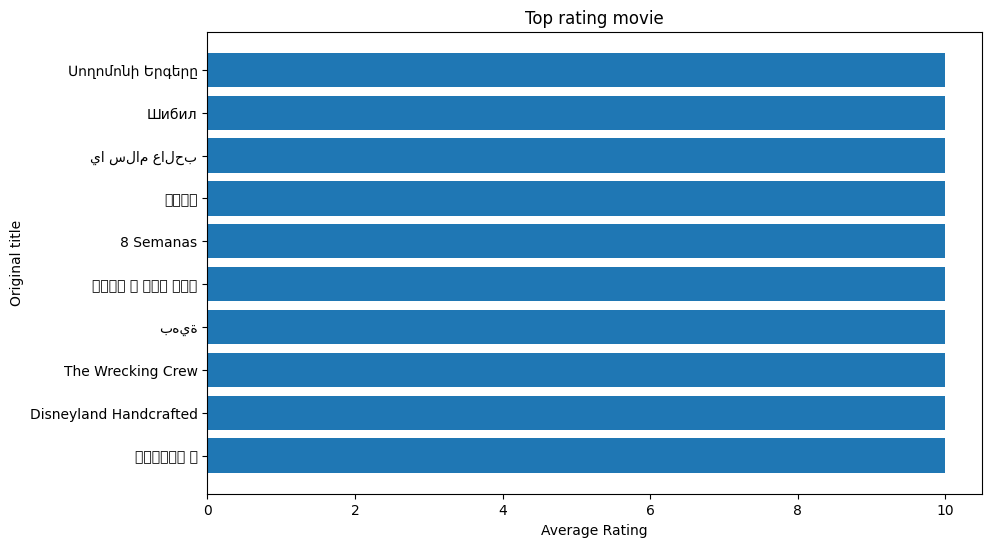

In [72]:
plt.figure(figsize=(10,6))
plt.barh(top_movies['original_title'],top_movies['vote_average'])
plt.xlabel('Average Rating')
plt.ylabel("Original title")
plt.title("Top rating movie")
plt.show()

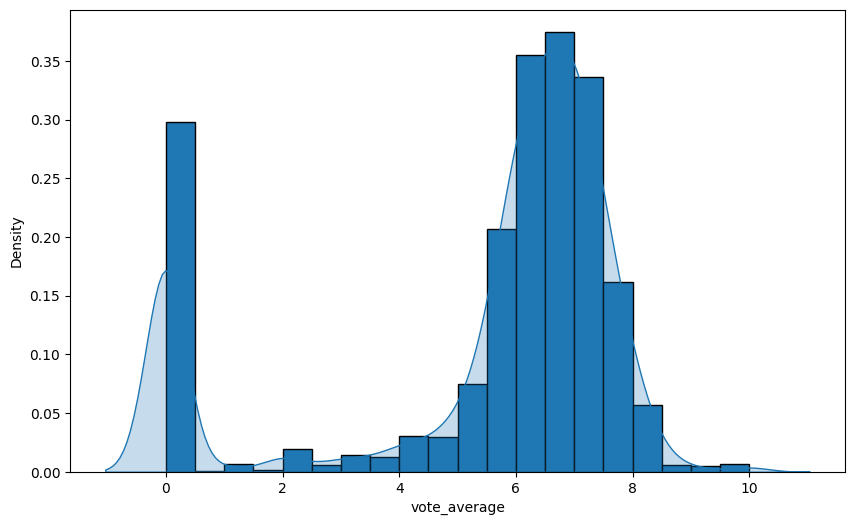

In [87]:
import seaborn as sns
plt.figure(figsize=(10,6))
plt.hist(df['vote_average'],bins=20,density=True,edgecolor='black')
sns.kdeplot(df['vote_average'],fill=True)
plt.show()

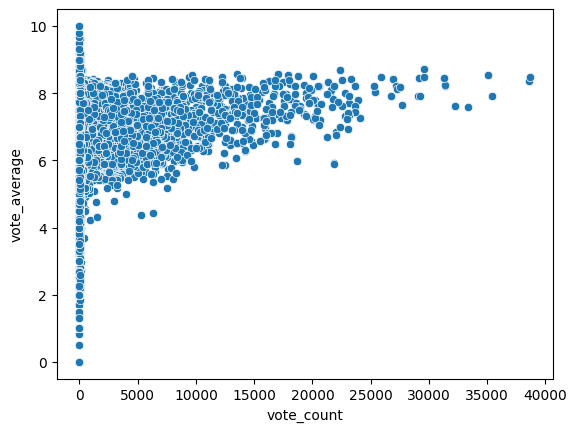

In [91]:
sns.scatterplot(x=df['vote_count'],y=df['vote_average'])
plt.show()